# Auto-Annotation & EDA

In [2]:
!pip install ultralytics matplotlib pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.4 MB/s eta 0:00:0000:01


Loading pre-trained YOLO11 model for auto-annotation...
Annotating 76 images...
Auto-annotation complete! Generated 76 label files in '../data/labels'.
Total workers annotated: 68

Generating Annotation Statistics Chart...
Chart saved to '../reports\worker_distribution.png'


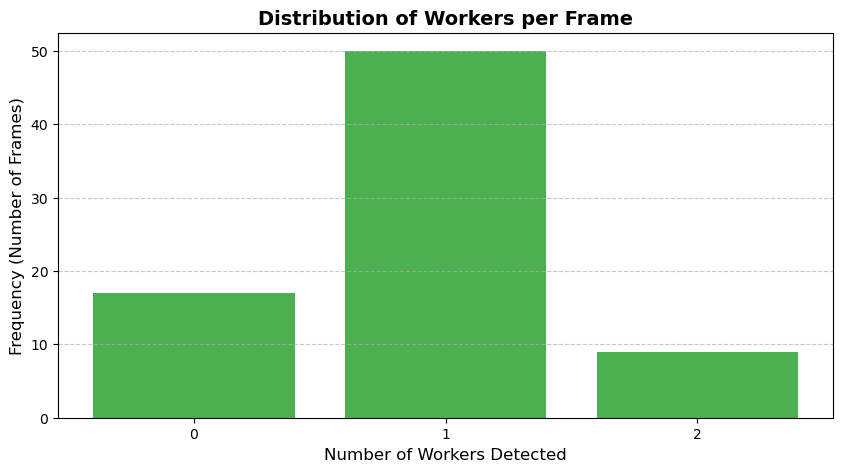

In [ ]:
import os
import glob
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Define paths
RAW_DIR = "../data/raw"
LABEL_DIR = "../data/labels"
REPORTS_DIR = "../reports"
os.makedirs(LABEL_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

# 1. Auto-Annotation (Simulating manual labeling)
print("Loading pre-trained YOLO11 model for auto-annotation...")
model = YOLO("yolo11n.pt") # Using the nano model for speed

image_paths = sorted(glob.glob(os.path.join(RAW_DIR, "*.jpg")))
total_workers_detected = 0
boxes_per_image = []

print(f"Annotating {len(image_paths)} images...")

for img_path in image_paths:
    img_name = os.path.basename(img_path)
    txt_name = img_name.replace(".jpg", ".txt")
    txt_path = os.path.join(LABEL_DIR, txt_name)
    
    # Run inference silently
    results = model(img_path, verbose=False)
    
    worker_count = 0
    with open(txt_path, "w") as f:
        for box in results[0].boxes:
            # Class 0 is 'person' in the COCO dataset
            if int(box.cls[0]) == 0: 
                # YOLO format: class x_center y_center width height (normalized)
                x, y, w, h = box.xywhn[0].tolist()
                f.write(f"0 {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")
                worker_count += 1
                total_workers_detected += 1
                
    boxes_per_image.append(worker_count)

print(f"Auto-annotation complete! Generated {len(image_paths)} label files in '{LABEL_DIR}'.")
print(f"Total workers annotated: {total_workers_detected}")

# 2. Annotation Analysis (Exploratory Data Analysis)
print("\nGenerating Annotation Statistics Chart...")
plt.figure(figsize=(10, 5))
plt.hist(boxes_per_image, bins=range(max(boxes_per_image)+2), align='left', rwidth=0.8, color='#4CAF50')
plt.title('Distribution of Workers per Frame', fontsize=14, fontweight='bold')
plt.xlabel('Number of Workers Detected', fontsize=12)
plt.ylabel('Frequency (Number of Frames)', fontsize=12)
plt.xticks(range(max(boxes_per_image)+1))
plt.grid(axis='y', linestyle='--', alpha=0.7)

chart_path = os.path.join(REPORTS_DIR, "worker_distribution.png")
plt.savefig(chart_path, bbox_inches='tight')
print(f"Chart saved to '{chart_path}'")
plt.show()